# **Machine Learning Modelling**

> For the purpose of this research, three machine learning models were trained using two separate dataset.
`raw data` which contains raw concrete ingredients and `enhaced-data` which contains engneering -based features.

```python
X_raw_data = ['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer',
       'coarse_aggregate', 'fine_aggregate', 'age']

eng_fea = ["w_c", "binder", "w_b", "agg_ratio"]
X_eng_data = raw_data + eng_fea

y = ["compressive_strength"]

```

The machine learning models include:
1. Linear Regression Model
2. Random Forest and 
3. XGBoost Regression



import machine learning libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error



load two datasets and split them into features and labels respectively.

In [2]:
raw_data = pd.read_csv("../data/raw_data.csv")
eng_data = pd.read_csv("../data/eng_data.csv")

raw_data.head()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
1,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.029847
2,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.447770
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.854291
4,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.289790


In [5]:
eng_data.head()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength,w_c,binder,w_b,agg_ratio
0,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366,0.300000,540.0,0.30,0.640758
1,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.029847,0.857143,380.0,0.60,0.718884
2,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.447770,0.600000,475.0,0.48,0.637339
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.854291,0.857143,380.0,0.60,0.718884
4,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.289790,0.480000,475.0,0.48,0.637339


In [3]:
# Features
X_raw = raw_data.drop("compressive_strength", axis = 1).values
X_eng = eng_data.drop("compressive_strength", axis=1).values

# Label
y = raw_data["compressive_strength"].values


In [4]:
# Training machine learning models Using raw data
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=100)

# Linear Regression (Baseline)
lr = LinearRegression()
lr.fit(X_train_raw, y_train)

# Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=100)
rf.fit(X_train_raw, y_train)

# XGBoost
xgb = XGBRegressor(n_estimators= 200, learning_rate = 0.05, max_depth = 5)
xgb.fit(X_train_raw, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


**evaluating model performance**

In [5]:
def evaluate(model, X_test, y_test):
    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    print(f"R2: ", r2, "RMSE: ", rmse, "MAE: ", mae)
    return r2, rmse, mae 

In [6]:
lr_results_raw = evaluate(lr, X_test_raw, y_test)

R2:  0.7548126642662316 RMSE:  7.964341930464569 MAE:  6.177749813039405


In [7]:
rf_results_raw = evaluate(rf, X_test_raw, y_test)

R2:  0.9300503411450096 RMSE:  4.253962726911572 MAE:  3.230239414820232


In [8]:
xgb_results_raw = evaluate(xgb, X_test_raw, y_test)

R2:  0.9458256886027908 RMSE:  3.7436701774492134 MAE:  2.8736186067155622


In [9]:
# Training models using engineering data

X_train_eng, X_test_eng, y_train, y_test = train_test_split(X_eng, y, test_size=0.2, random_state=100)

# Linear Regression (Baseline)
lr = LinearRegression()
lr.fit(X_train_eng, y_train)

# Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=100)
rf.fit(X_train_eng, y_train)

# XGBoost
xgb = XGBRegressor(n_estimators= 200, learning_rate = 0.05, max_depth = 5)
xgb.fit(X_train_eng, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [10]:
lr_results_eng = evaluate(lr, X_test_eng, y_test)

R2:  0.7597467691232281 RMSE:  7.883798182971417 MAE:  6.0629394871516595


In [11]:
rf_results_eng = evaluate(rf, X_test_eng, y_test)

R2:  0.9388659780398956 RMSE:  3.976878879448238 MAE:  2.9964411522347887


In [12]:
xgb_results_eng = evaluate(xgb, X_test_eng, y_test)

R2:  0.9549459771982907 RMSE:  3.4140326265214394 MAE:  2.6038260283422265


In [13]:
results = {
    "raw" :{
        "lr": {
            "r2": 0.75481,
            "rmse": 7.96344,
            "mae": 6.17777

        },
        "rf": {
            "r2": 0.93005,
            "rmse": 4.25396,
            "mae": 3.23024
        },
        "xgb": {
            "r2": 0.94583,
            "rmse": 3.74367,
            "mae": 2.87368
        }

    },
    "eng" : {
        "lr": {
            "r2": 0.75975,
            "rmse": 7.88379,
            "mae": 6.06294   
        },
        "rf": {
            "r2":  0.938866,
            "rmse": 3.97688,
            "mae": 2.99644
        },
        "xgb": {
            "r2": 0.954946,
            "rmse": 3.41403,
            "mae": 2.603826
        }
    }
}

### **Generate Predictions** 

In [14]:
def get_predictions(model, X_train, X_test, y_train):
    model.fit(X_train, y_train)
    return model.predict(X_test)

#raw
lr_pred_r = get_predictions(lr, X_train_raw, X_test_raw, y_train)
rf_pred_r = get_predictions(rf, X_train_raw, X_test_raw, y_train)
xgb_pred_r = get_predictions(xgb, X_train_raw, X_test_raw, y_train)

# Enginered
lr_pred_e = get_predictions(lr, X_train_eng, X_test_eng, y_train)
rf_pred_e = get_predictions(rf, X_train_eng, X_test_eng, y_train)
xgb_pred_e =get_predictions(rf, X_train_eng, X_test_eng, y_train)

model_predictions = {
    "LR_raw": lr_pred_r,
    "LR_eng": lr_pred_e,
    "RF_raw": rf_pred_r,
    "RF_eng": rf_pred_e,
    "XGB_raw": xgb_pred_r,
    "XGB_eng": xgb_pred_e
}

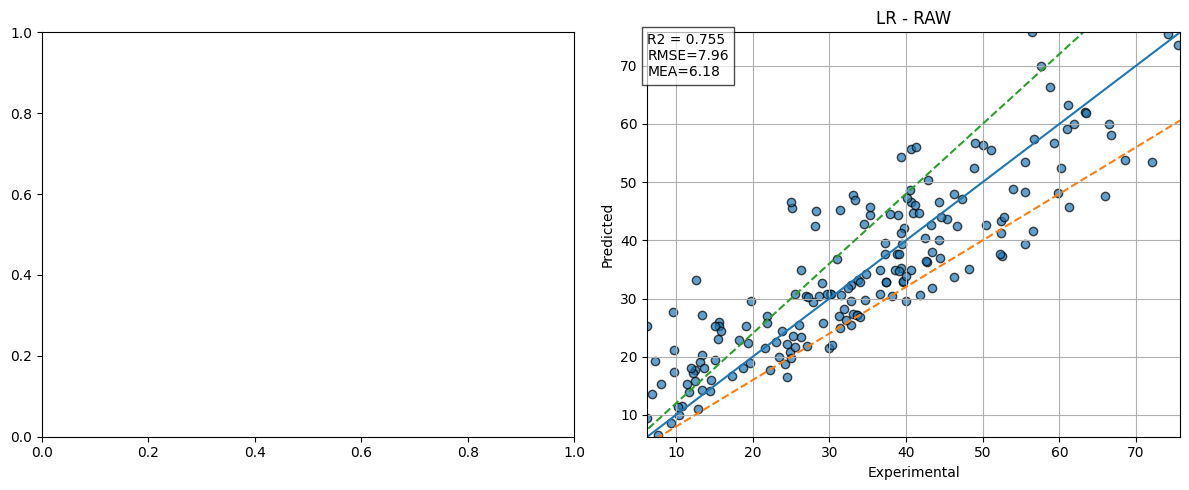

<Figure size 640x480 with 0 Axes>

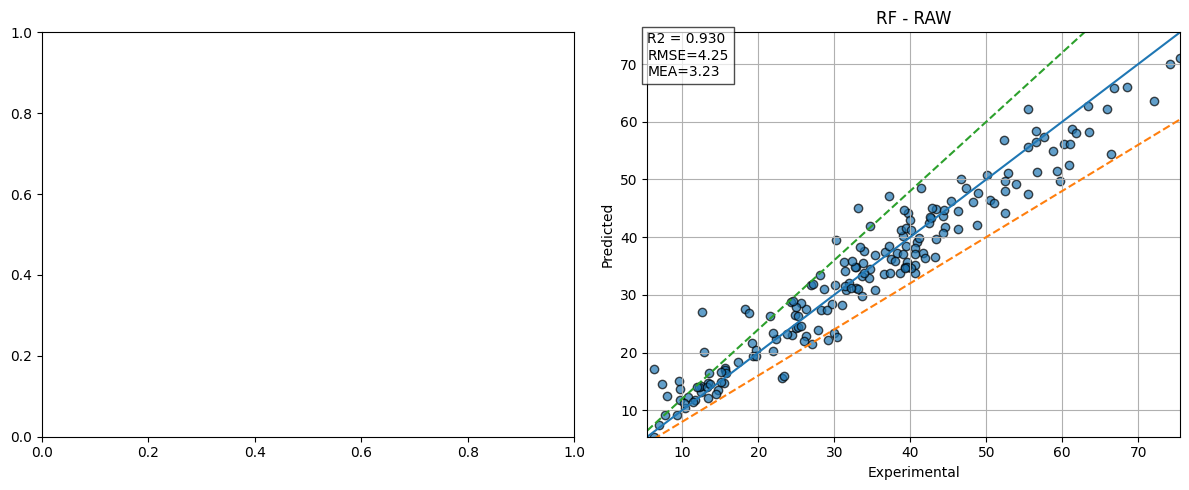

<Figure size 640x480 with 0 Axes>

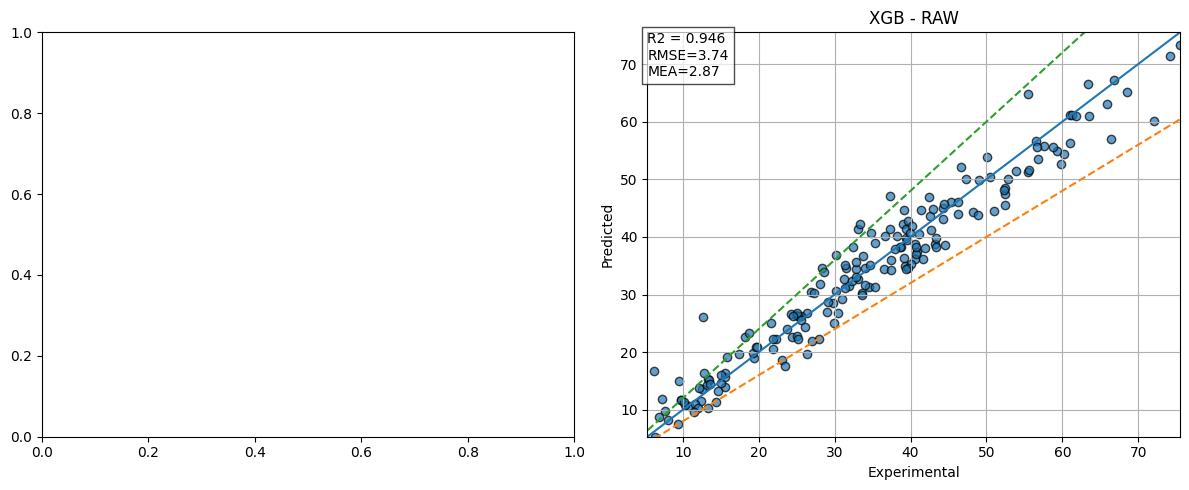

<Figure size 640x480 with 0 Axes>

In [15]:
models = ["LR", "RF", "XGB"]

for model in models:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for i, feature_type in enumerate(["raw", "eng"]):
        ax = axes[1]
        key = f"{model}_{feature_type}"
        y_pred = model_predictions[key]

        ax.scatter(y_test, y_pred, alpha=0.7, edgecolor='k')

        #perfect line
        min_val = min(y_test.min(), y_pred.min())
        max_val = max(y_test.max(), y_pred.max())
        ax.plot([min_val, max_val], [min_val, max_val])
        ax.plot([0, max_val], [0, 0.8*max_val], linestyle = '--')
        ax.plot([0, max_val], [0, 1.2*max_val], linestyle = '--')

        #metrics
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)

        ax.text(min_val, max_val*0.9,
                f"R2 = {r2:.3f}\nRMSE={rmse:.2f}\nMEA={mae:.2f}",
                bbox = dict(facecolor ='white', alpha =0.7))
        
        ax.set_title(f"{model} - {feature_type.upper()}")
        ax.set_xlabel("Experimental")
        ax.set_ylabel("Predicted")
        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)
        ax.grid(True)

        plt.tight_layout()
        plt.show()
